# Data Observation

In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
from baseline_methods.continuous_naive_Bayesian_classifier import *

In [2]:
TRAIN_FILE_NUMBERS = 11020
TRAIN_USER_NUMBERS = 60

TEST_FILE_NUMBERS = 6849
TEST_USER_NUMBERS = 40

In [3]:
def file_csv_to_df(train, file_id, user_id = 0, g_to_ms2 = 9.81):
    if (train):
        assert 1 <= file_id and file_id <= TRAIN_FILE_NUMBERS
        assert 0 <= user_id and user_id <= TRAIN_USER_NUMBERS
        folder = "train"
    else:
        assert TRAIN_FILE_NUMBERS + 1 <= file_id and file_id <= TRAIN_FILE_NUMBERS + TEST_FILE_NUMBERS
        assert TRAIN_USER_NUMBERS <= user_id and user_id <= TRAIN_USER_NUMBERS + TEST_USER_NUMBERS
        folder = "test"
    
    if ((train and user_id != 0) or (not train and user_id != 60)):
        df = pd.read_csv(f'data/{folder}/User_{user_id:03d}/{file_id:05d}.csv')
        df['mean_x'] *= g_to_ms2
        df['mean_y'] *= g_to_ms2
        df['mean_z'] *= g_to_ms2
        df['std_x'] *= g_to_ms2
        df['std_y'] *= g_to_ms2
        df['std_z'] *= g_to_ms2
        return df
    
    pattern = f"data/{folder}/User_*/{file_id:05d}.csv"
    matches = glob.glob(pattern)

    if len(matches) == 0:
        raise FileNotFoundError(f"No file found for file_id={file_id}")

    df = pd.read_csv(matches[0])
    df['mean_x'] *= g_to_ms2
    df['mean_y'] *= g_to_ms2
    df['mean_z'] *= g_to_ms2
    df['std_x'] *= g_to_ms2
    df['std_y'] *= g_to_ms2
    df['std_z'] *= g_to_ms2
    return df

def user_csv_to_dfs(train, user_id, g_to_ms2 = 9.81):
    if (train):
        assert 1 <= user_id and user_id <= TRAIN_USER_NUMBERS
        folder = "train"
    else:
        assert TRAIN_USER_NUMBERS + 1 <= user_id and user_id <= TRAIN_USER_NUMBERS + TEST_USER_NUMBERS
        folder = "test"

    pattern = f"data/{folder}/User_{user_id:03d}/*.csv"
    matches = glob.glob(pattern)

    if len(matches) == 0:
        raise FileNotFoundError(f"No file found for user_id={user_id}")

    dfs = []

    for csv in matches:
        df = pd.read_csv(csv)
        df['mean_x'] *= g_to_ms2
        df['mean_y'] *= g_to_ms2
        df['mean_z'] *= g_to_ms2
        df['std_x'] *= g_to_ms2
        df['std_y'] *= g_to_ms2
        df['std_z'] *= g_to_ms2
        
        dfs.append(df)
    
    return dfs

def add_xyz_speed_position(df):
    x_means = df['mean_x'].to_numpy()
    y_means = df['mean_y'].to_numpy()
    z_means = df['mean_z'].to_numpy()

    x_speeds = [x_means[0]]
    y_speeds = [y_means[0]]
    z_speeds = [z_means[0]]

    x_positions = [x_speeds[0]]
    y_positions = [y_speeds[0]]
    z_positions = [z_speeds[0]]

    for i in range(1, len(x_means)):
        x_speeds.append(x_speeds[i - 1] + x_means[i])
        y_speeds.append(y_speeds[i - 1] + y_means[i])
        z_speeds.append(z_speeds[i - 1] + z_means[i])

        x_positions.append(x_positions[i - 1] + x_speeds[i])
        y_positions.append(y_positions[i - 1] + y_speeds[i])
        z_positions.append(z_positions[i - 1] + z_speeds[i])
    
    df['speed_x'] = x_speeds
    df['speed_y'] = y_speeds
    df['speed_z'] = z_speeds

    df['position_x'] = x_positions
    df['position_y'] = y_positions
    df['position_z'] = z_positions

    return df

In [4]:
def data_frame_accelerations_to_figures(df):
    fig, axes = plt.subplots(3, 1, figsize=(15, 6), sharex=True)

    seconds = df['index']

    axes_map = {
        0: ('x axis', 'mean_x', 'std_x'),
        1: ('y axis', 'mean_y', 'std_y'),
        2: ('z axis', 'mean_z', 'std_z'),
    }

    for i, (label, mean_col, std_col) in axes_map.items():
        mean = df[mean_col]
        std = df[std_col]

        ax = axes[i]

        ax.plot(seconds, mean, color='blue', label='mean', lw = 0.5)

        ax.fill_between(
            seconds,
            mean - std,
            mean + std,
            color='blue',
            alpha=0.2,
            label='± std'
        )

        ax.set_title(label)
        ax.legend()

    fig.supylabel("acceleration [m/s²]")
    fig.supxlabel("time [seconds]")

    plt.tight_layout()
    plt.show()

def data_frame_speeds_to_figures(df):
    fig, axes = plt.subplots(3, 1, figsize=(15, 6), sharex=True)

    seconds = df['index']

    axes_map = {
        0: ('x axis', 'speed_x'),
        1: ('y axis', 'speed_y'),
        2: ('z axis', 'speed_z'),
    }

    for i, (label, speed_col) in axes_map.items():
        speed = df[speed_col]

        ax = axes[i]

        ax.plot(seconds, speed, color='blue', lw = 0.5)

        ax.set_title(label)

    fig.supylabel("speed [m/s]")
    fig.supxlabel("time [seconds]")

    plt.tight_layout()
    plt.show()

def data_frame_positions_to_figures(df):
    fig, axes = plt.subplots(3, 1, figsize=(15, 6), sharex=True)

    seconds = df['index']

    axes_map = {
        0: ('x axis', 'position_x'),
        1: ('y axis', 'position_y'),
        2: ('z axis', 'position_z'),
    }

    for i, (label, position_col) in axes_map.items():
        position = df[position_col]

        ax = axes[i]

        ax.plot(seconds, position, color='blue', lw = 0.5)

        ax.set_title(label)

    fig.supylabel("position [meters]")
    fig.supxlabel("time [seconds]")

    plt.tight_layout()
    plt.show()

def data_frame_to_figures(df):
    data_frame_accelerations_to_figures(df)
    if ('speed_x' in df.columns):
        data_frame_speeds_to_figures(df)
    if ('position_x' in df.columns):
        data_frame_positions_to_figures(df)

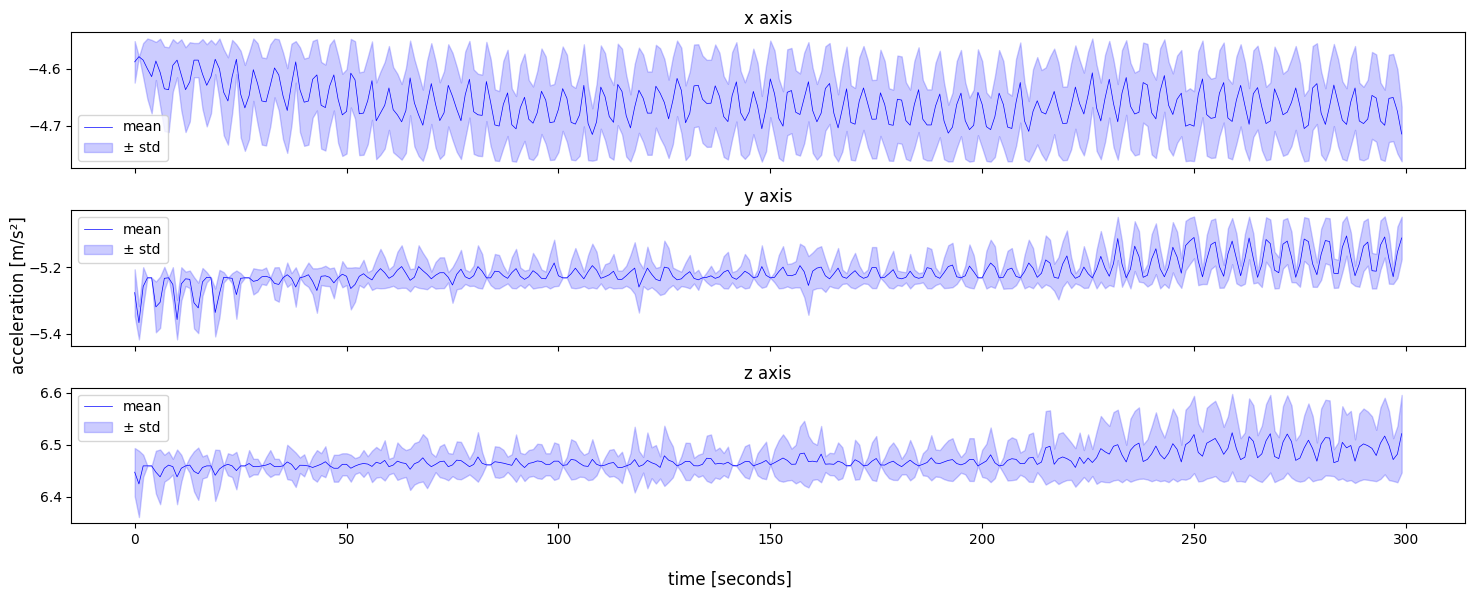

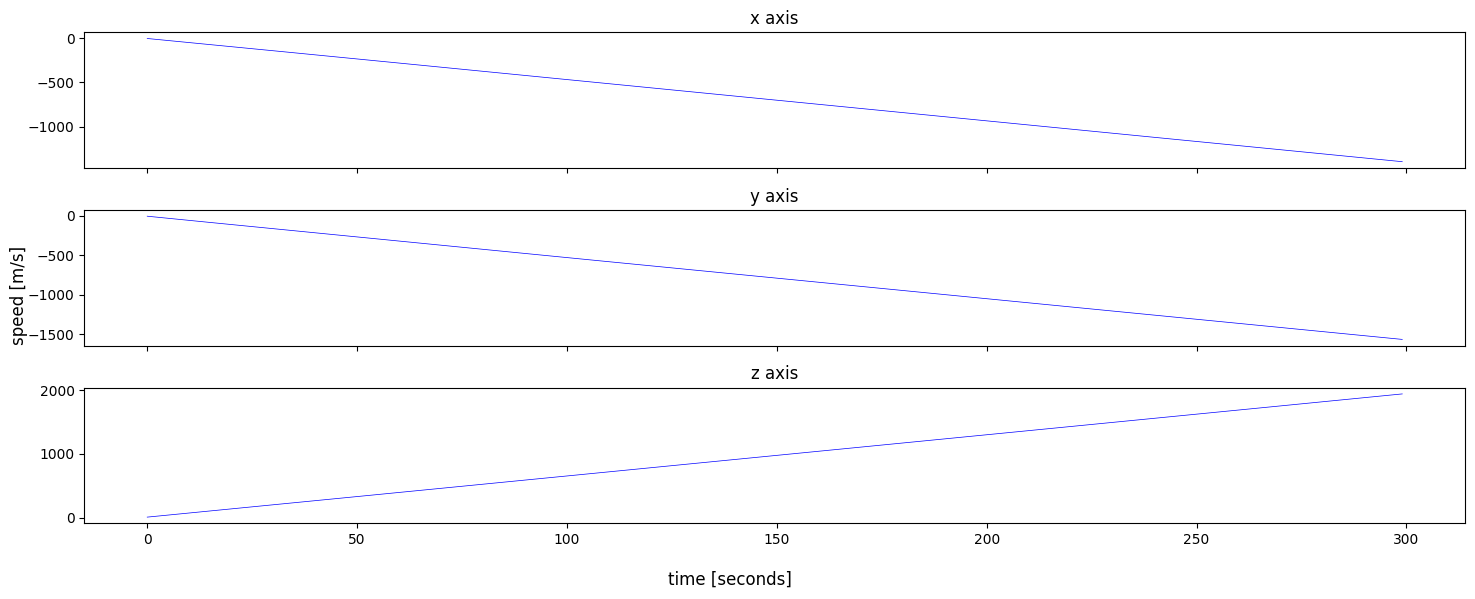

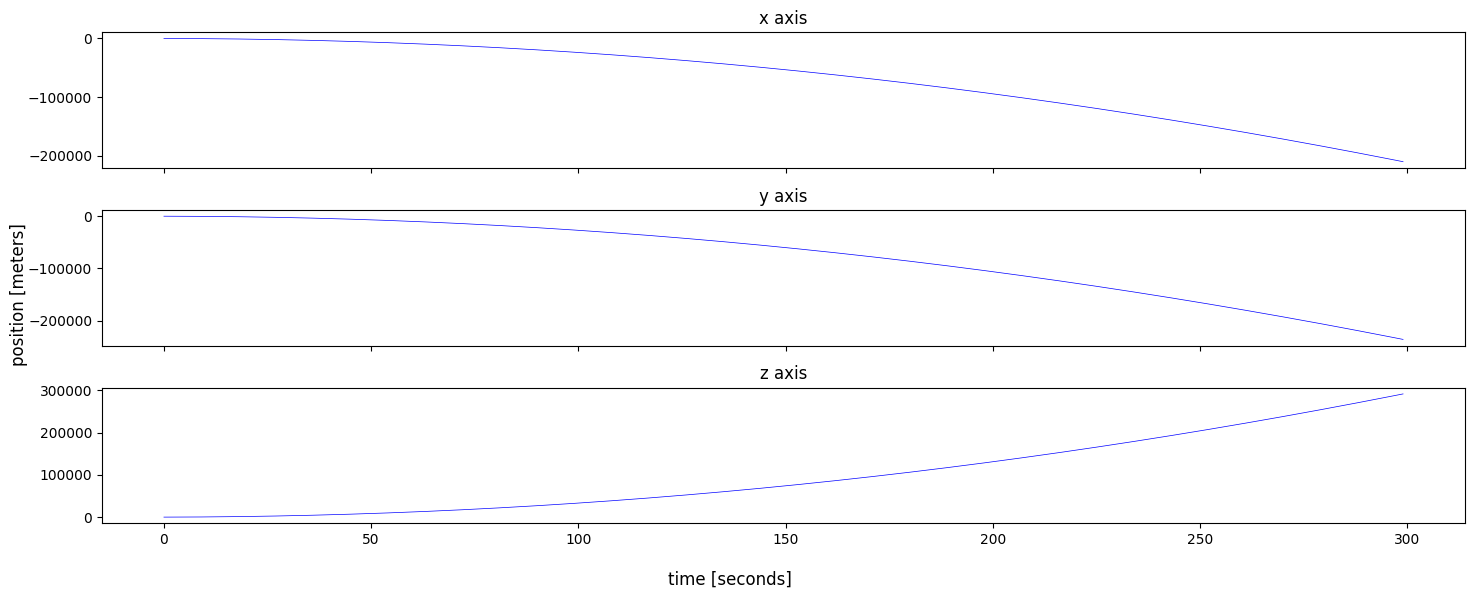

In [5]:
df = file_csv_to_df(True, 1)
df.head()
df = add_xyz_speed_position(df)
df.head()
data_frame_to_figures(df)

In [6]:
seen = [False for _ in range(6)]
df_list = [None for _ in range(6)]
cnt = 0

i = 0
while cnt <= 5:
    i += 1
    df = file_csv_to_df(True, i)
    label = df['label'][0]
    if (not seen[label]):
        df_list[label] = df
        seen[label] = True
        cnt += 1
        print(f"label: {label} | file_id: {i}")

label: 0 | file_id: 1
label: 3 | file_id: 50
label: 5 | file_id: 51
label: 1 | file_id: 63
label: 2 | file_id: 71
label: 4 | file_id: 596


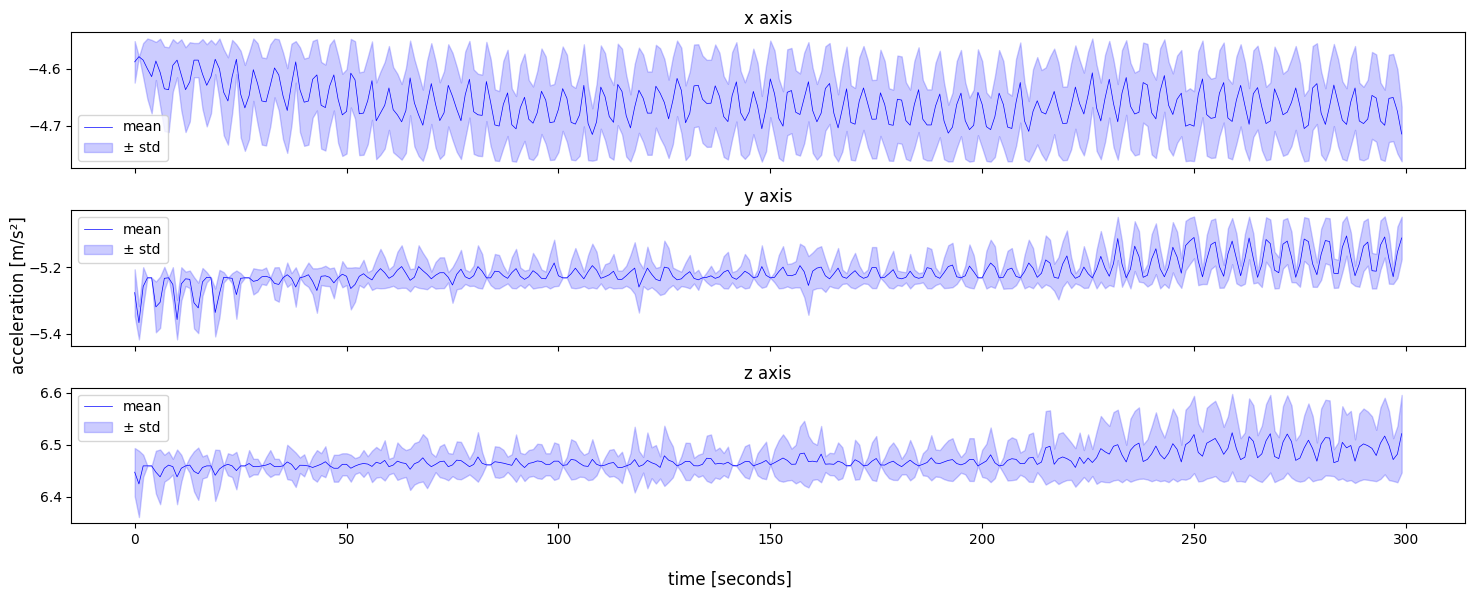

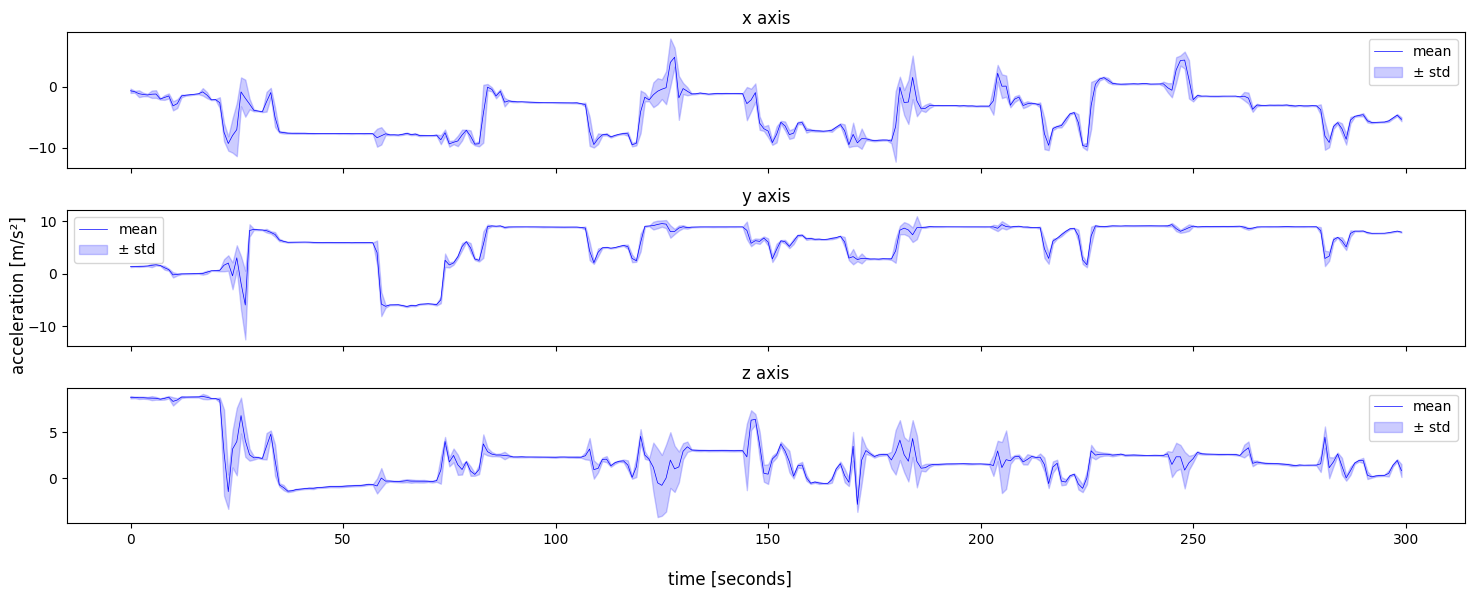

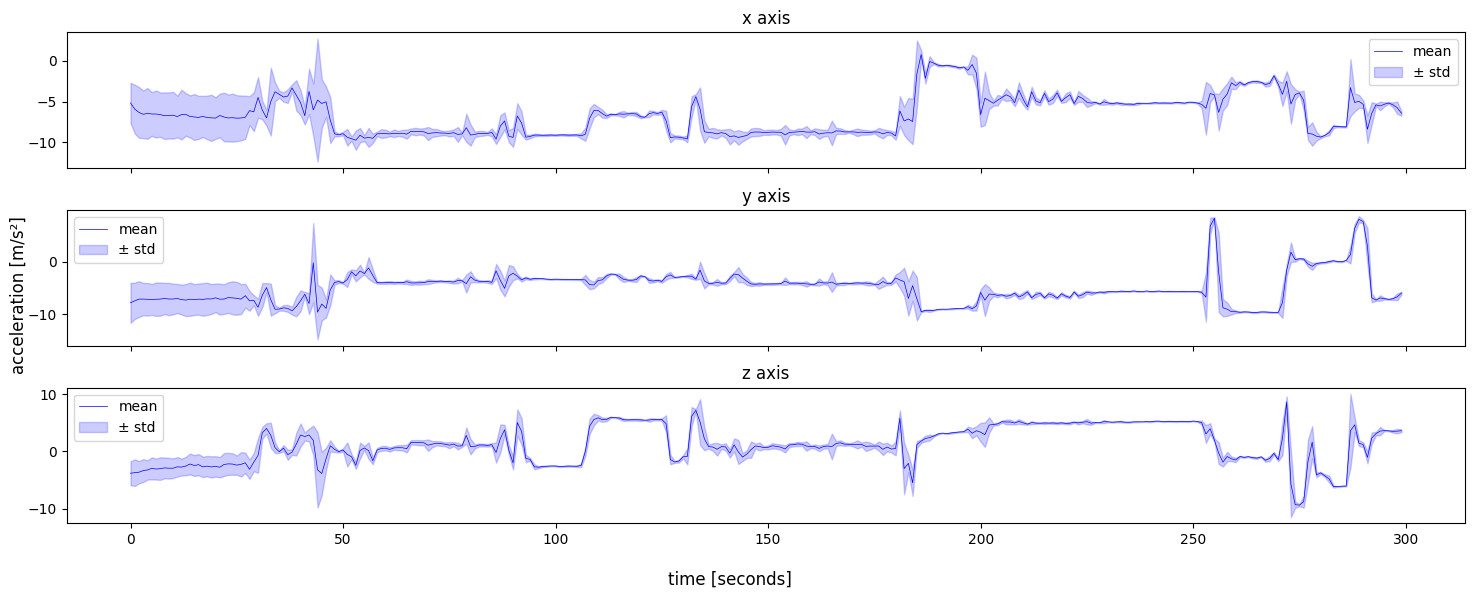

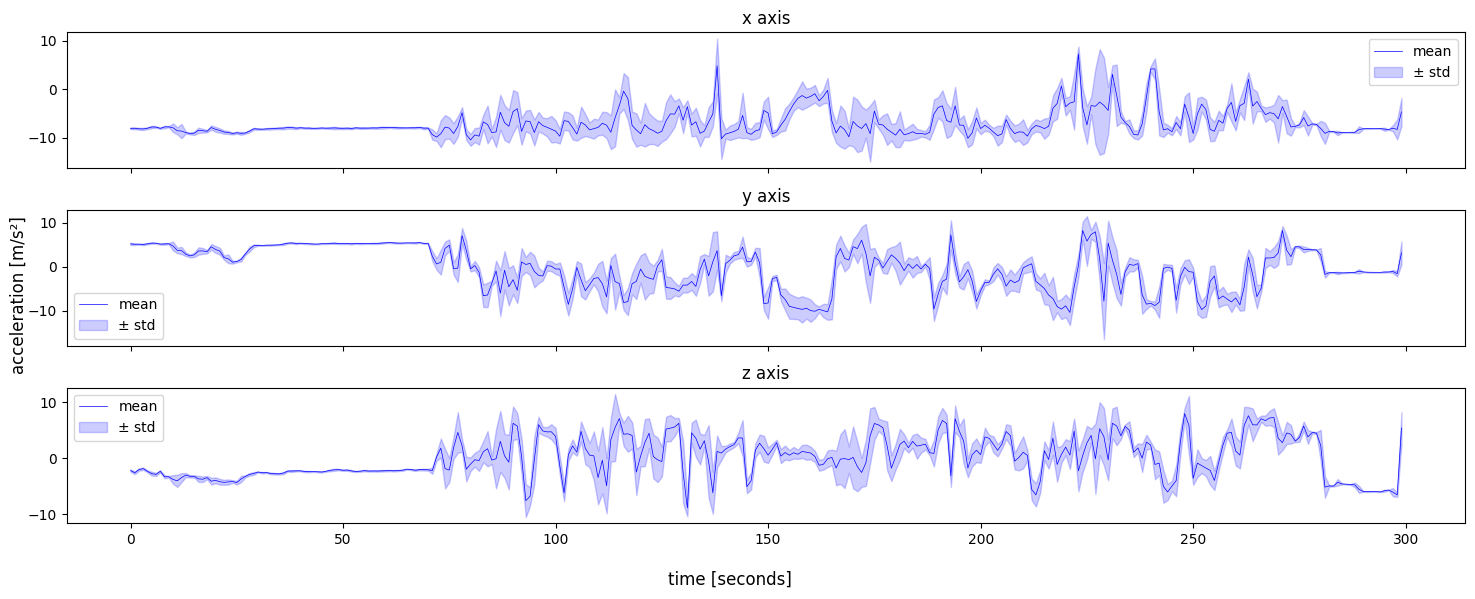

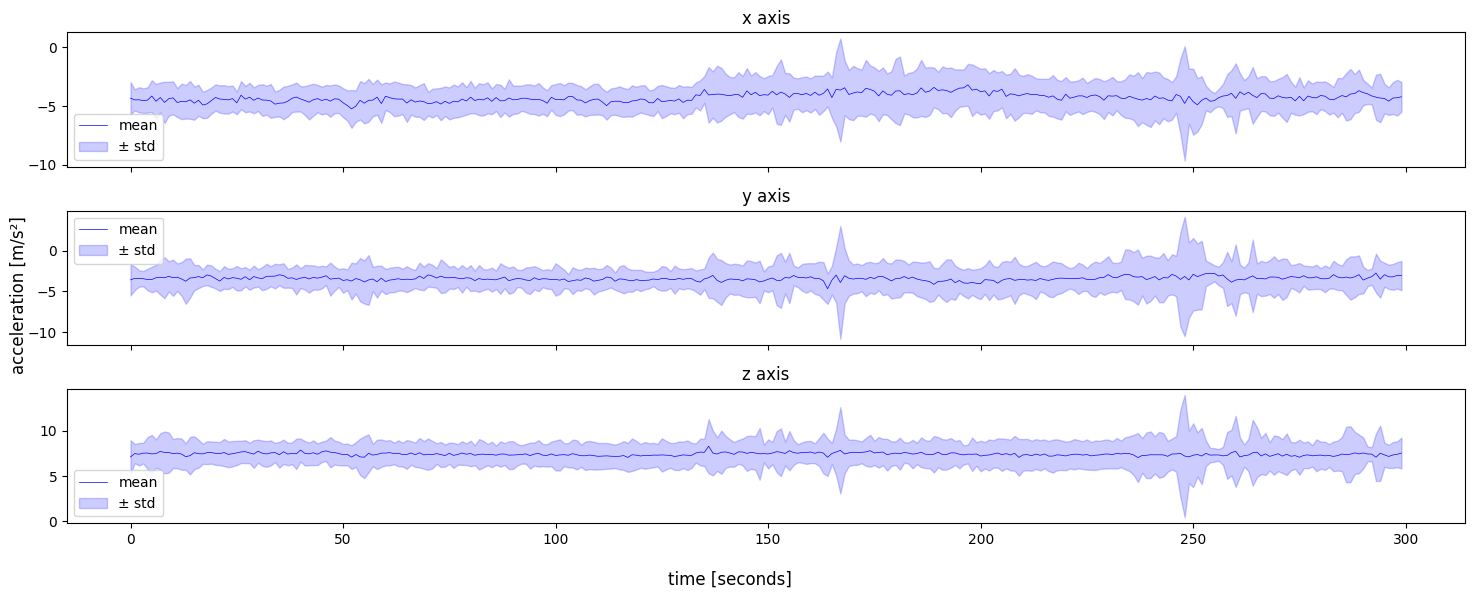

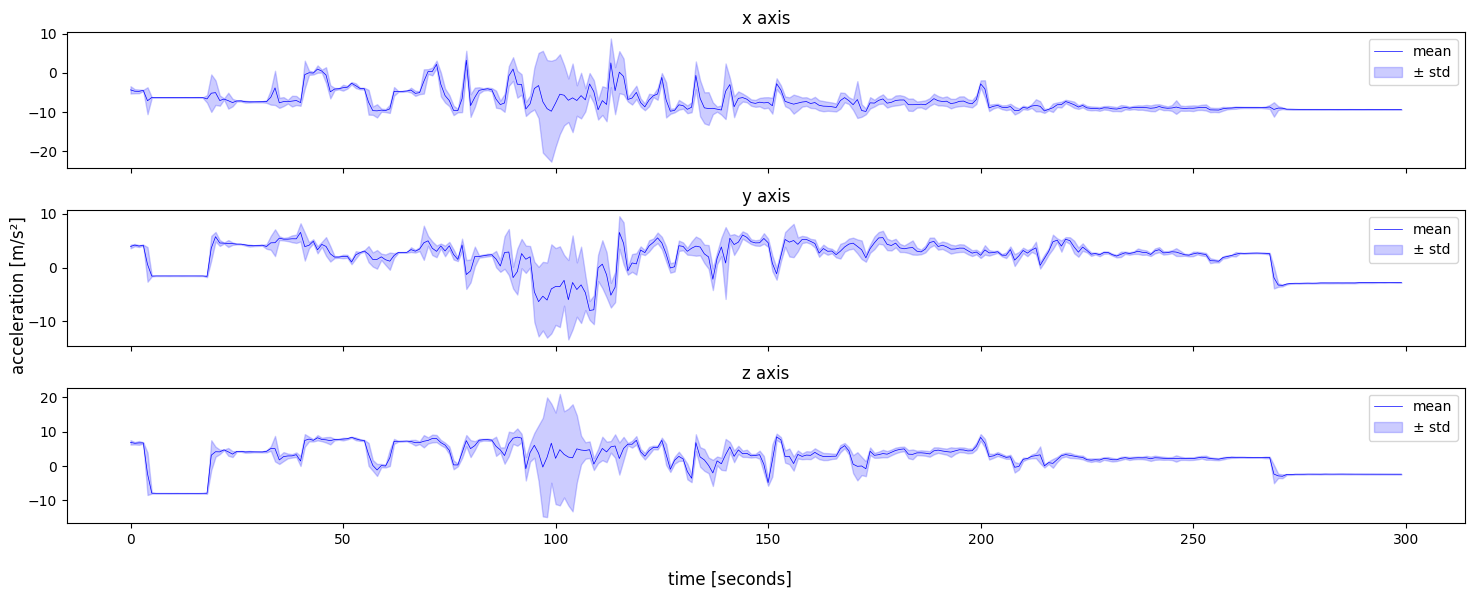

In [7]:
for i in range(6):
    data_frame_to_figures(df_list[i])